<a href="https://colab.research.google.com/github/ArthiNelwadkar/EV-Data-Analysis/blob/main/Data_Exploration_EV_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
1: What are the top 5 most common EV makes and models in the dataset?

import pandas as pd

# Step 1: Load dataset
df = pd.read_csv("Electric_Vehicle_Population_Data.csv")

# Step 2: Top 5 EV Makes
top_makes = df['Make'].value_counts().head(5)
print("Top 5 EV Makes:")
print(top_makes)

# Step 3: Top 5 EV Models
top_models = df['Model'].value_counts().head(5)
print("\nTop 5 EV Models:")
print(top_models)

Object `dataset` not found.
Top 5 EV Makes:
Make
TESLA        114817
CHEVROLET     19410
NISSAN        16153
FORD          15423
KIA           14101
Name: count, dtype: int64

Top 5 EV Models:
Model
MODEL Y    60361
MODEL 3    37836
LEAF       13499
MODEL S     7735
BOLT EV     7701
Name: count, dtype: int64


In [2]:
2: What is the distribution of EVs by county? Which county has the most registrations?

import pandas as pd

# Step 1: Load dataset
df = pd.read_csv("Electric_Vehicle_Population_Data.csv")

# Step 2: Count EVs by County
county_counts = df['County'].value_counts()

# Step 3: Display distribution
print("EV Distribution by County:")
print(county_counts)

# Step 4: Identify county with most registrations
top_county = county_counts.idxmax()
top_count = county_counts.max()
print(f"\nCounty with most registrations: {top_county} ({top_count} EVs)")

Object `registrations` not found.
EV Distribution by County:
County
King         138276
Snohomish     35137
Pierce        23041
Clark         17315
Thurston      10220
              ...  
Anchorage         1
Escambia          1
Otero             1
Lexington         1
Sussex            1
Name: count, Length: 250, dtype: int64

County with most registrations: King (138276 EVs)


Object `years` not found.
EV Adoption by Model Year:
Model Year
1999        2
2000        7
2002        1
2003        1
2008       19
2010       22
2011      573
2012     1366
2013     3914
2014     3173
2015     4394
2016     5068
2017     8400
2018    13958
2019    10777
2020    12042
2021    20746
2022    29924
2023    60333
2024    49544
2025    36867
2026    19678
2027       24
Name: count, dtype: int64


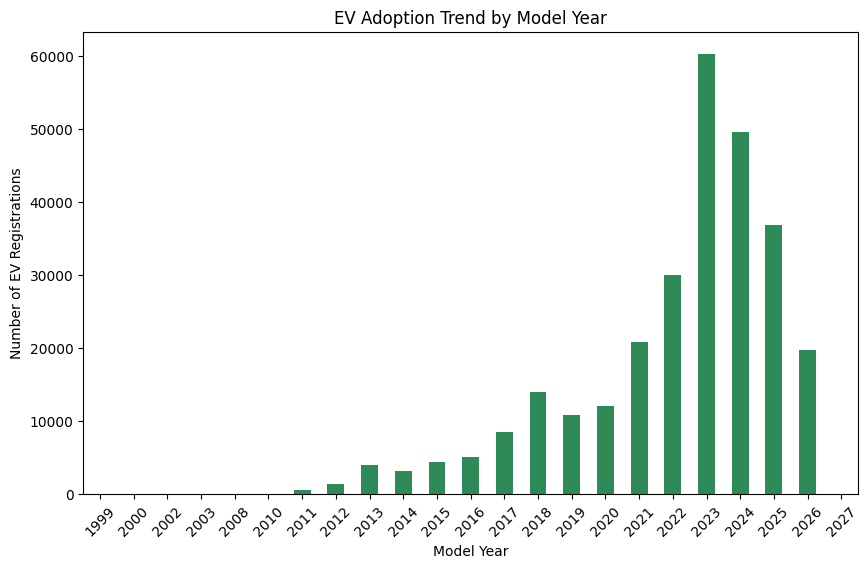

In [3]:
3: How has EV adoption changed over different model years?

import pandas as pd
import matplotlib.pyplot as plt

# Step 1: Load dataset
df = pd.read_csv("Electric_Vehicle_Population_Data.csv")

# Step 2: Count EVs by Model Year
year_counts = df['Model Year'].value_counts().sort_index()

# Step 3: Display distribution
print("EV Adoption by Model Year:")
print(year_counts)

# Step 4: Visualize adoption trend
plt.figure(figsize=(10,6))
year_counts.plot(kind='bar', color='seagreen')
plt.title("EV Adoption Trend by Model Year")
plt.xlabel("Model Year")
plt.ylabel("Number of EV Registrations")
plt.xticks(rotation=45)
plt.show()


In [4]:
4: What is the average electric range of EVs in the dataset?

import pandas as pd

# Step 1: Load dataset
df = pd.read_csv("Electric_Vehicle_Population_Data.csv")

# Step 2: Handle missing or zero values (treat them as NaN)
df['Electric Range'] = df['Electric Range'].replace(0, pd.NA)

# Step 3: Calculate average electric range
avg_range = df['Electric Range'].dropna().mean()

print(f"Average Electric Range of EVs: {avg_range:.2f} miles")

Object `dataset` not found.
Average Electric Range of EVs: 107.46 miles


In [6]:
5: What percentage of EVs are eligible for Clean Alternative Fuel Vehicle (CAFV) incentives?

# Step 1: Load dataset
df = pd.read_csv("Electric_Vehicle_Population_Data.csv")

# Step 2: Check CAFV eligibility column
print(df['Clean Alternative Fuel Vehicle (CAFV) Eligibility'].unique())

# Step 3: Count eligible vs total
eligible_count = df[df['Clean Alternative Fuel Vehicle (CAFV) Eligibility'] == 'Clean Alternative Fuel Vehicle Eligible'].shape[0]
total_count = df.shape[0]

# Step 4: Calculate percentage
percentage = (eligible_count / total_count) * 100
print(f"Percentage of EVs eligible for CAFV incentives: {percentage:.2f}%")

df['Clean Alternative Fuel Vehicle (CAFV) Eligibility'].value_counts(normalize=True) * 100


Object `incentives` not found.
['Clean Alternative Fuel Vehicle Eligible'
 'Eligibility unknown as battery range has not been researched'
 'Not eligible due to low battery range']
Percentage of EVs eligible for CAFV incentives: 27.47%


,proportion
Clean Alternative Fuel Vehicle (CAFV) Eligibility,
Eligibility unknown as battery range has not been researched,63.930521
Clean Alternative Fuel Vehicle Eligible,27.465789
Not eligible due to low battery range,8.603690


Object `models` not found.
Average Electric Range by Make & Model:
Make       Model   
PORSCHE    MACAN            303.0
TESLA      MODEL Y          291.0
HYUNDAI    KONA             258.0
CHEVROLET  BOLT EV     244.660012
TESLA      MODEL X     241.704517
           MODEL 3     238.252955
           ROADSTER    235.217391
JAGUAR     I-PACE           234.0
POLESTAR   PS2              233.0
TESLA      MODEL S      228.26691
Name: Electric Range, dtype: object


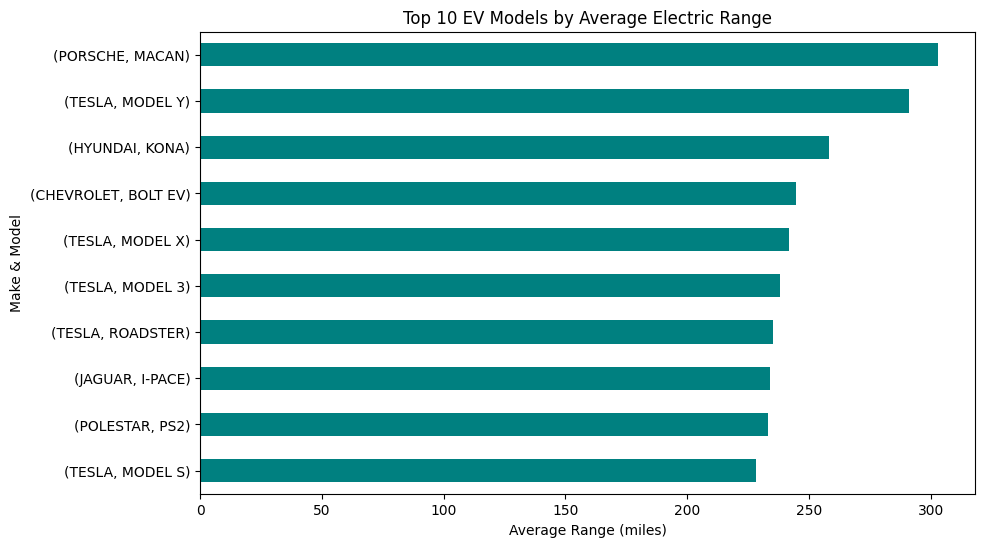

In [7]:
6: How does the electric range vary across different makes and models?

import pandas as pd
import matplotlib.pyplot as plt

# Step 1: Load dataset
df = pd.read_csv("Electric_Vehicle_Population_Data.csv")

# Step 2: Handle missing or zero values in Electric Range
df['Electric Range'] = df['Electric Range'].replace(0, pd.NA)

# Step 3: Calculate average range by Make and Model
range_by_make_model = (
    df.groupby(['Make','Model'])['Electric Range']
      .mean()
      .sort_values(ascending=False)
)

print("Average Electric Range by Make & Model:")
print(range_by_make_model.head(10))  # top 10

# Step 4: Visualize top 10 models by average range
top10 = range_by_make_model.head(10)
top10.plot(kind='barh', figsize=(10,6), color='teal')
plt.title("Top 10 EV Models by Average Electric Range")
plt.xlabel("Average Range (miles)")
plt.ylabel("Make & Model")
plt.gca().invert_yaxis()
plt.show()


In [1]:
7: What is the average Base MSRP for each EV model?

import pandas as pd

# Load datasets
ev_df = pd.read_csv("Electric_Vehicle_Population_Data.csv")
msrp_df = pd.read_csv("EV_MSRP_Data.csv")

# Normalize names for merging
ev_df['Make'] = ev_df['Make'].str.strip().str.lower()
ev_df['Model'] = ev_df['Model'].str.strip().str.lower()
msrp_df['Make'] = msrp_df['Make'].str.strip().str.lower()
msrp_df['Model'] = msrp_df['Model'].str.strip().str.lower()

# Clean MSRP column
msrp_df.rename(columns={'Base MSRP':'BaseMSRP'}, inplace=True)
msrp_df['BaseMSRP'] = msrp_df['BaseMSRP'].replace('[\$,]', '', regex=True).astype(float)

# Merge datasets
merged_df = pd.merge(ev_df, msrp_df[['Make','Model','BaseMSRP']], on=['Make','Model'], how='inner')

# Calculate average Base MSRP per EV model
avg_msrp = merged_df.groupby(['Make','Model'])['BaseMSRP'].mean().reset_index()

print(avg_msrp)



<>:17: SyntaxWarning: invalid escape sequence '\$'
<>:17: SyntaxWarning: invalid escape sequence '\$'
/tmp/ipykernel_1302/4106122766.py:17: SyntaxWarning: invalid escape sequence '\$'
  msrp_df['BaseMSRP'] = msrp_df['BaseMSRP'].replace('[\$,]', '', regex=True).astype(float)


Object `model` not found.
         Make    Model  BaseMSRP
0   chevrolet  bolt ev   31995.0
1      nissan     leaf   28990.0
2      rivian      r1t   69900.0
3       tesla  model 3   39990.0
4       tesla  model s   74990.0
5       tesla  model x   79990.0
6       tesla  model y   47990.0
7  volkswagen     id.4   38995.0
8       volvo     ex30   44990.0


Unique counties in dataset:
['King' 'Kitsap' 'Thurston' 'Snohomish' 'Island' 'Yakima' 'Whitman'
 'Stevens' 'Skagit' 'Garfield' 'Grant' 'Walla Walla' 'Spokane' 'Pierce'
 'Douglas' 'Chelan' 'Okanogan' nan 'Clark' 'Jefferson' 'Cowlitz' 'Clallam'
 'Klickitat' 'Mason' 'Whatcom' 'Kittitas' 'Benton' 'Asotin' 'San Juan'
 'Pacific' 'Lewis' 'Franklin' 'Wahkiakum' 'Skamania' 'Columbia'
 'Grays Harbor' 'Lincoln' 'Ferry' 'Adams' 'Pend Oreille' 'San Diego'
 'Oldham' 'Lake' 'York' 'Arlington' 'Riverside' 'Santa Clara' 'Sacramento'
 'Laramie' 'Broward' 'Calvert' 'Fairfax' 'Goochland' 'Orange' 'Autauga'
 'Butte' 'Harford' 'Cumberland' 'Cochise' 'Maricopa' 'Los Angeles'
 'Alameda' 'Portsmouth' 'Chesapeake' 'Okaloosa' 'Charles' 'Buncombe'
 'Multnomah' 'Anne Arundel' 'Loudoun' 'Shelby' 'Newport' 'Muscogee'
 'Umatilla' 'Moore' 'Berkeley' 'Bucks' 'Pinal' 'Washington' 'Hudson'
 "Prince George's" 'Burlington' 'Marin' 'Kern' 'Providence' 'Duval'
 'Centre' 'Caddo' "St. Mary's" 'Monterey' 'District of Columbia'


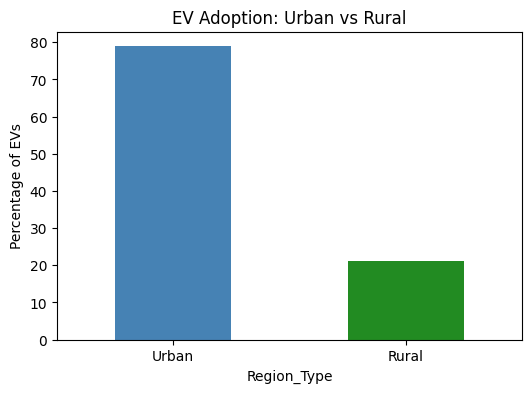

In [12]:
#8: Are there any regional trends in EV adoption ?

import pandas as pd
import matplotlib.pyplot as plt

# Step 1: Load dataset
df = pd.read_csv("Electric_Vehicle_Population_Data.csv")

# Step 2: Inspect county values
print("Unique counties in dataset:")
print(df['County'].unique())

# Step 3: Define urban counties (example list, adjust to your region)
urban_counties = ['King', 'Pierce', 'Snohomish', 'Clark', 'Spokane']  # replace with your known urban counties

# Step 4: Classify each record as Urban or Rural
df['Region_Type'] = df['County'].apply(lambda x: 'Urban' if x in urban_counties else 'Rural')

# Step 5: Count EVs by region type
region_counts = df['Region_Type'].value_counts()
region_percent = df['Region_Type'].value_counts(normalize=True) * 100

print("\nEV Adoption by Region Type:")
print(region_counts)
print("\nPercentage Split:")
print(region_percent)

# Step 6: Visualize adoption (Urban vs Rural)
plt.figure(figsize=(6,4))
region_percent.plot(kind='bar', color=['steelblue','forestgreen'])
plt.title("EV Adoption: Urban vs Rural")
plt.ylabel("Percentage of EVs")
plt.xticks(rotation=0)
plt.show()
